# Genomics RNA-seq Analysis

Exploratory RNA-seq analysis comparing APOEhi macrophages against control macrophages.



## Data Source

The RNA-seq data used in this project were obtained from the supplementary materials of the following article:

https://doi.org/10.1016/j.canlet.2026.218605

This analysis is exploratory and was performed for educational purposes.

In [122]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from adjustText import adjust_text

## Load Data

In [120]:
df = pd.read_excel("rnaseq-01.xlsx")

df.head()

,"Supplementary Data 4. RNA-Seq of ApoE-hi, ApoE-lo, and ApoE-Ctr THP-1 macrophages",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,gene_id,GeneSymbol,Description,Exonic.gene.sizes,Control-1 (FPKM),Control-2 (FPKM),Control-3 (FPKM),APOEhi-1 (FPKM),APOEhi-2 (FPKM),APOEhi-3 (FPKM),APOElo-1 (FPKM),APOElo-2 (FPKM),APOElo-3 (FPKM),NaN,NaN
1,ENSG00000000003,TSPAN6,tetraspanin 6 [Source:HGNC Symbol%3BAcc:HGNC:1...,4536,0.53,0.52,0.43,0.28,0.32,0.42,1.64,1.72,1.52,NaN,NaN
2,ENSG00000000005,TNMD,tenomodulin [Source:HGNC Symbol%3BAcc:HGNC:17757],1476,0,0,0,0,0,0,0,0,0,NaN,NaN
3,ENSG00000000419,DPM1,dolichyl-phosphate mannosyltransferase subunit...,9276,5.34,6.07,5.85,8.41,7.59,6.94,6.03,5.88,5.94,NaN,NaN
4,ENSG00000000457,SCYL3,SCY1 like pseudokinase 3 [Source:HGNC Symbol%3...,6883,2.47,2.42,2.7,2.72,3.12,3.32,3.65,3.68,3.5,NaN,NaN


## Data Cleaning

In [121]:
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df = df.loc[:, ~df.columns.isna()]

numeric_cols = [
    "Control-1 (FPKM)",
    "Control-2 (FPKM)",
    "Control-3 (FPKM)",
    "APOEhi-1 (FPKM)",
    "APOEhi-2 (FPKM)",
    "APOEhi-3 (FPKM)",
    "APOElo-1 (FPKM)",
    "APOElo-2 (FPKM)",
    "APOElo-3 (FPKM)"
]

df[numeric_cols] = df[numeric_cols].astype(float)
df["Exonic.gene.sizes"] = pd.to_numeric(df["Exonic.gene.sizes"])

df.head()

,gene_id,GeneSymbol,Description,Exonic.gene.sizes,Control-1 (FPKM),Control-2 (FPKM),Control-3 (FPKM),APOEhi-1 (FPKM),APOEhi-2 (FPKM),APOEhi-3 (FPKM),APOElo-1 (FPKM),APOElo-2 (FPKM),APOElo-3 (FPKM)
0,ENSG00000000003,TSPAN6,tetraspanin 6 [Source:HGNC Symbol%3BAcc:HGNC:1...,4536,0.53,0.52,0.43,0.28,0.32,0.42,1.64,1.72,1.52
1,ENSG00000000005,TNMD,tenomodulin [Source:HGNC Symbol%3BAcc:HGNC:17757],1476,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,ENSG00000000419,DPM1,dolichyl-phosphate mannosyltransferase subunit...,9276,5.34,6.07,5.85,8.41,7.59,6.94,6.03,5.88,5.94
3,ENSG00000000457,SCYL3,SCY1 like pseudokinase 3 [Source:HGNC Symbol%3...,6883,2.47,2.42,2.70,2.72,3.12,3.32,3.65,3.68,3.50
4,ENSG00000000460,C1orf112,chromosome 1 open reading frame 112 [Source:HG...,5970,2.75,2.29,2.81,2.19,2.36,2.58,3.79,3.77,3.91


## Mean Expression and Fold Change

In [123]:
control_cols = [
    "Control-1 (FPKM)",
    "Control-2 (FPKM)",
    "Control-3 (FPKM)"
]

apoehi_cols = [
    "APOEhi-1 (FPKM)",
    "APOEhi-2 (FPKM)",
    "APOEhi-3 (FPKM)"
]

apoelo_cols = [
    "APOElo-1 (FPKM)",
    "APOElo-2 (FPKM)",
    "APOElo-3 (FPKM)"
]

df["Control_mean"] = df[control_cols].mean(axis=1)
df["APOEhi_mean"] = df[apoehi_cols].mean(axis=1)
df["APOElo_mean"] = df[apoelo_cols].mean(axis=1)

pseudocount = 0.001

df["log2FC_APOEhi_vs_Control"] = np.log2(
    (df["APOEhi_mean"] + pseudocount) /
    (df["Control_mean"] + pseudocount)
)

df[[
    "GeneSymbol",
    "Control_mean",
    "APOEhi_mean",
    "log2FC_APOEhi_vs_Control"
]].head()

,GeneSymbol,Control_mean,APOEhi_mean,log2FC_APOEhi_vs_Control
0,TSPAN6,0.493333,0.340000,-0.535712
1,TNMD,0.000000,0.000000,0.000000
2,DPM1,5.753333,7.646667,0.410371
3,SCYL3,2.530000,3.053333,0.271150
4,C1orf112,2.616667,2.376667,-0.138735


## Differential Expression Analysis

In [124]:
expression_cols = control_cols + apoehi_cols

df_volcano = df[
    df[expression_cols].mean(axis=1) > 1
].copy()

df_volcano = df_volcano[
    df_volcano["GeneSymbol"].notna() &
    (df_volcano["GeneSymbol"] != "-")
].copy()

df_volcano["Control_mean"] = df_volcano[control_cols].mean(axis=1)
df_volcano["APOEhi_mean"] = df_volcano[apoehi_cols].mean(axis=1)

df_volcano["log2FC_APOEhi_vs_Control"] = np.log2(
    (df_volcano["APOEhi_mean"] + pseudocount) /
    (df_volcano["Control_mean"] + pseudocount)
)

control = np.log2(df_volcano[control_cols] + 1)
apoehi = np.log2(df_volcano[apoehi_cols] + 1)

pvals = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    for i in range(len(df_volcano)):
        _, p = stats.ttest_ind(
            apoehi.iloc[i],
            control.iloc[i],
            equal_var=False
        )
        pvals.append(p)

df_volcano["p_value"] = np.nan_to_num(pvals, nan=1.0)

p = df_volcano["p_value"].values
m = len(p)

order = np.argsort(p)
rank = np.empty(m)
rank[order] = np.arange(1, m + 1)

fdr = p * m / rank
fdr_sorted = fdr[order]
fdr_sorted = np.minimum.accumulate(fdr_sorted[::-1])[::-1]

df_volcano["FDR"] = np.empty(m)
df_volcano.loc[df_volcano.index[order], "FDR"] = np.minimum(fdr_sorted, 1)

df_volcano["neg_log10_FDR"] = -np.log10(df_volcano["FDR"] + 1e-300)

df_volcano["significance"] = "Not significant"

df_volcano.loc[
    (df_volcano["log2FC_APOEhi_vs_Control"] > 1) &
    (df_volcano["FDR"] < 0.05),
    "significance"
] = "Upregulated"

df_volcano.loc[
    (df_volcano["log2FC_APOEhi_vs_Control"] < -1) &
    (df_volcano["FDR"] < 0.05),
    "significance"
] = "Downregulated"

df_volcano["significance"].value_counts()

significance
Not significant    10426
Downregulated        636
Upregulated          401
Name: count, dtype: int64

## Volcano Plot

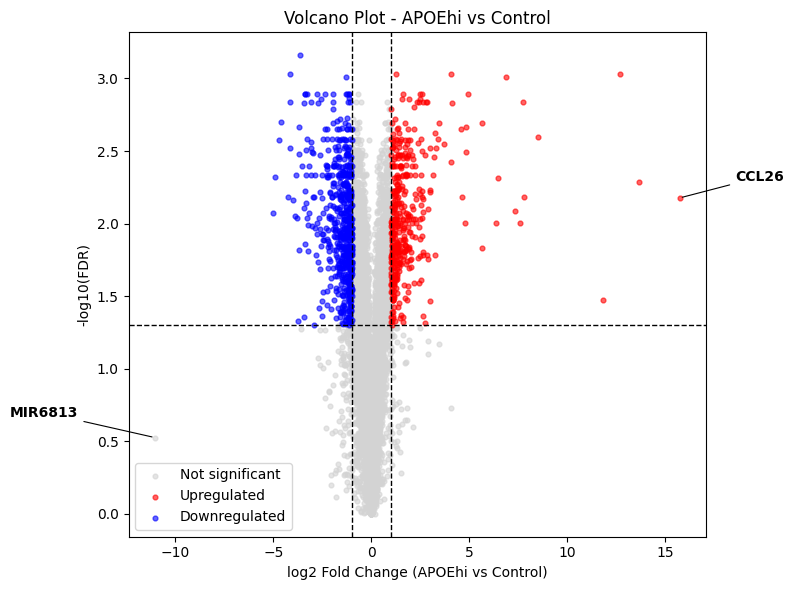

In [125]:
os.makedirs("figures", exist_ok=True)

colors = {
    "Not significant": "lightgray",
    "Upregulated": "red",
    "Downregulated": "blue"
}

plt.figure(figsize=(8, 6))

for group, color in colors.items():
    subset = df_volcano[df_volcano["significance"] == group]

    plt.scatter(
        subset["log2FC_APOEhi_vs_Control"],
        subset["neg_log10_FDR"],
        c=color,
        label=group,
        alpha=0.6,
        s=12
    )

plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.axvline(-1, color="black", linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)

top_up = df_volcano.sort_values(
    "log2FC_APOEhi_vs_Control",
    ascending=False
).head(1)

top_down = df_volcano.sort_values(
    "log2FC_APOEhi_vs_Control",
    ascending=True
).head(1)

top_labels = pd.concat([top_up, top_down])

for _, row in top_labels.iterrows():
    x = row["log2FC_APOEhi_vs_Control"]
    y = row["neg_log10_FDR"]
    gene = row["GeneSymbol"]

    if x > 0:
        offset = (40, 15)
        ha = "left"
    else:
        offset = (-55, 18)
        ha = "right"

    plt.annotate(
        gene,
        xy=(x, y),
        xytext=offset,
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="black",
        ha=ha,
        va="center",
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            linewidth=0.8
        )
    )

plt.xlabel("log2 Fold Change (APOEhi vs Control)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot - APOEhi vs Control")
plt.legend()

plt.tight_layout()
plt.savefig("figures/volcano_corrected_labeled_top1.png", dpi=300)
plt.show()

 ## Principal Component Analysis (PCA)

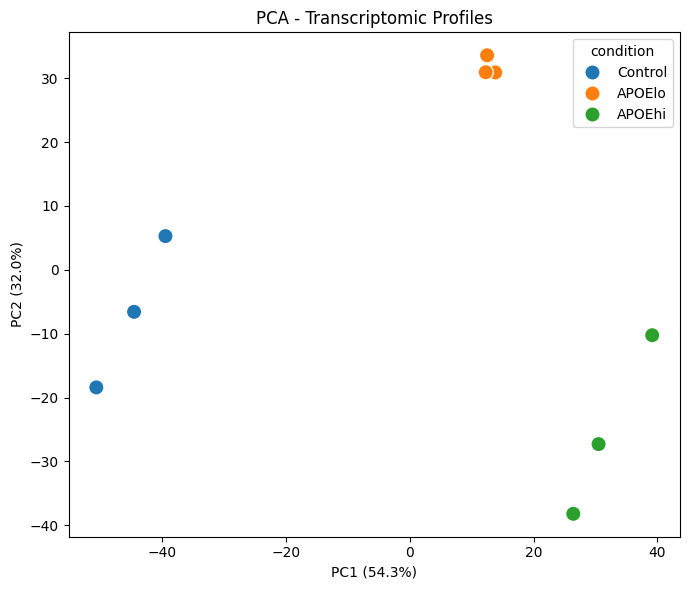

In [126]:
pca_cols = control_cols + apoelo_cols + apoehi_cols

df_pca = df[
    df[pca_cols].mean(axis=1) > 1
].copy()

df_pca["variance"] = df_pca[pca_cols].var(axis=1)
df_pca = df_pca.sort_values("variance", ascending=False).head(2000)

X = df_pca[pca_cols].T
X = np.log2(X + 1)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    components,
    columns=["PC1", "PC2"]
)

pca_df["condition"] = [
    "Control", "Control", "Control",
    "APOElo", "APOElo", "APOElo",
    "APOEhi", "APOEhi", "APOEhi"
]

plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="condition",
    s=120
)

plt.title("PCA - Transcriptomic Profiles")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")

plt.tight_layout()
plt.savefig("figures/pca.png", dpi=300)
plt.show()

## Top Differentially Expressed Genes

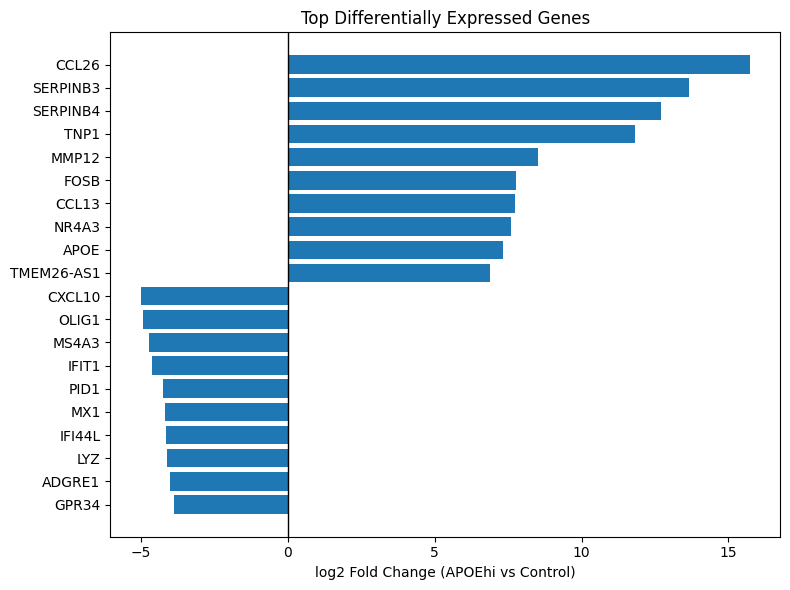

In [127]:
sig_genes = df_volcano[
    (abs(df_volcano["log2FC_APOEhi_vs_Control"]) > 1) &
    (df_volcano["FDR"] < 0.05)
].copy()

top_up = sig_genes.sort_values(
    "log2FC_APOEhi_vs_Control",
    ascending=False
).head(10)

top_down = sig_genes.sort_values(
    "log2FC_APOEhi_vs_Control",
    ascending=True
).head(10)

top_genes = pd.concat([top_up, top_down])

plt.figure(figsize=(8, 6))

plt.barh(
    top_genes["GeneSymbol"],
    top_genes["log2FC_APOEhi_vs_Control"]
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("log2 Fold Change (APOEhi vs Control)")
plt.title("Top Differentially Expressed Genes")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("figures/top_genes_clean.png", dpi=300)
plt.show()

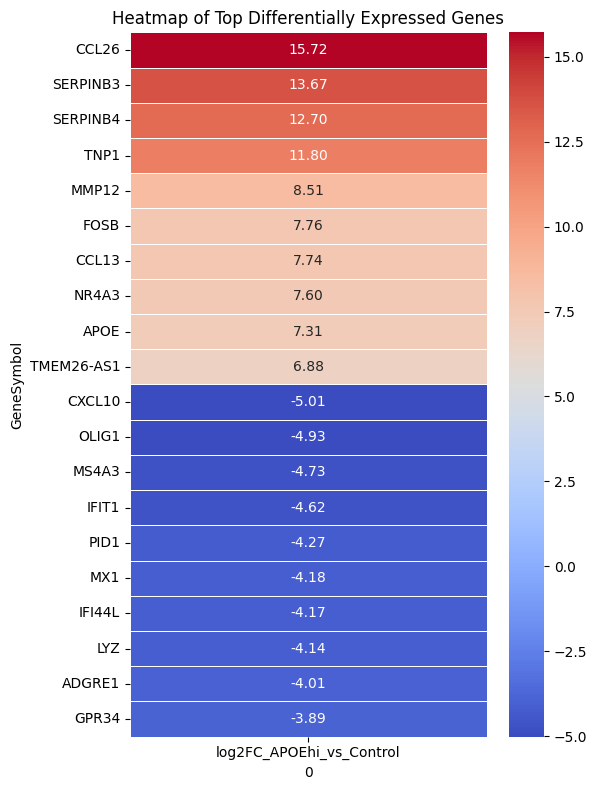

In [128]:
heatmap_data = top_genes[[
    "GeneSymbol",
    "log2FC_APOEhi_vs_Control"
]].set_index("GeneSymbol")

plt.figure(figsize=(6, 8))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap of Top Differentially Expressed Genes")

plt.tight_layout()
plt.savefig("figures/heatmap_clean.png", dpi=300)
plt.show()

In [ ]:
# Export full DE results table for GitHub / CV reuse
os.makedirs("figures", exist_ok=True)

de_export = df_volcano[
    [
        "GeneSymbol",
        "Control_mean",
        "APOEhi_mean",
        "log2FC_APOEhi_vs_Control",
        "p_value",
        "FDR",
        "significance",
    ]
].sort_values("FDR")

de_export.to_csv("figures/apoehi_vs_control_de_genes.csv", index=False)
de_export.head()
